## Introduction



---
### Install Qiskit

In [289]:
%%capture
!pip install qiskit --upgrade
!pip install qiskit-ibm-provider
!pip install pylatexenc
!pip install qiskit-aer

### Install the packages

In [274]:
import numpy as np
import qiskit
print('Qiskit Version', qiskit.__version__)
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix
import warnings
warnings.filterwarnings('ignore')

Qiskit Version 2.4.1


## Prepare a quantum superposition state

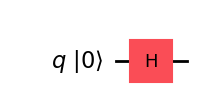

In [275]:
from qiskit.visualization import plot_bloch_multivector

# Initialize a quantum circuit with 1 qubit
qc = QuantumCircuit(1)

# Apply a Hadamard gate to the qubit to create a superposition state
qc.h(0)

# Draw the circuit
# print initial state with initial_state=True to show the statevector before applying any gates
qc.draw('mpl', initial_state=True)

## Visualize the state on the Bloch sphere

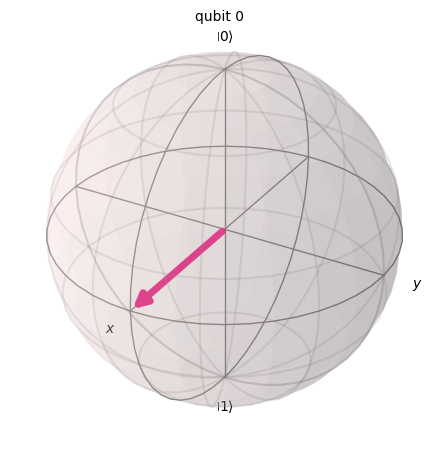

In [276]:
# get the statevector and plot it on the Bloch sphere
state = Statevector(qc)
plot_bloch_multivector(state)

## Visualize the effect of quantum gates on the Bloch sphere

**Question:** Can you visualize the effect of other quantum gates on the Bloch sphere? Try to add some gates to the circuit and visualize their effect.

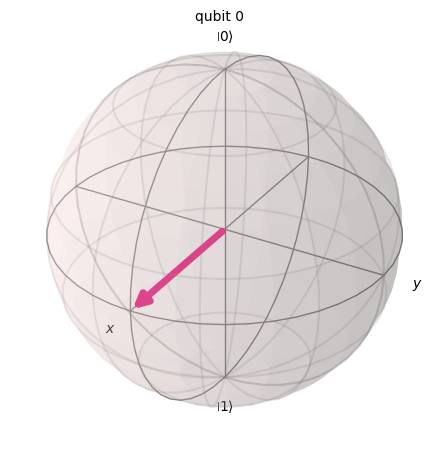

In [277]:
# visualize the gate action of some quantum gate on the Bloch sphere
qc = QuantumCircuit(1)

################TODO##################
# add the gates you want to visualize here Hadamard, Pauli-X, Pauli-Y, Pauli-Z, S, T, RX, RY, RZ etc.
# e.g. qc.x(0) or qc.h(0) or qc.s(0) or qc.t(0) or qc.rx(np.pi/4, 0) etc.

qc.ry(np.pi/2, 0)

####################################
qc.draw('mpl')
state = Statevector(qc)
plot_bloch_multivector(state)

## Create a Bell state



Bell states are maximally entangled two qubit states, exhibiting stronger than classical correlations (stronger than any classical local hidden variable model permits) independently of the distance between the two particles, i.e., the two qubits involved. In total, there are four Bell states, which can be created by applying a Hadamard gate to the first qubit and a CNOT gate to both two qubits involved, starting from the state $|00\rangle$:

The state $ |\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) $ is created as follows:

$ \ket{00} \xrightarrow{H \otimes I} \frac{1}{\sqrt{2}}(\ket{00} + \ket{10}) \xrightarrow{CNOT_{01}} \frac{1}{\sqrt{2}}(\ket{00} + \ket{11}) $

---
Let us now create the Bell state $ |\Phi^+\rangle $ using Qiskit and visualize the quantum circuit.


 **Question:** Can you try to adapt the circuit to create the other Bell states?

In [278]:
#intitialize a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# apply a Hadamard gate to the first qubit and a CNOT gate to create a Bell state
qc.h(0)
qc.cx(0, 1)

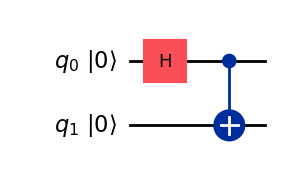

In [279]:
# plot the quantum circuit
qc.draw('mpl', initial_state=True)

Let us print the statevector and confirm it from the lecture slides:

In [280]:
# print the statevector of the Bell state
state = Statevector(qc)
print("Statevector:", state.data)

Statevector: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


---
## How can we visualize the output?

 **Question:** What changes if we prepare the other Bell states that we saw in the lecture? Can you prepare them and visualize the output?

In [281]:
# let us import the visualization functions we will use next
from qiskit.visualization import (
    plot_state_city,
    plot_state_qsphere,
    plot_state_hinton,
)

## Qsphere visualization of the Bell state
The color indicates the phase of the state. The size of the point is proportional to the probabilit o feach of the corresponding terms of the state. The Bell state $ |\Phi^+\rangle $ has two terms, $ |00\rangle $ and $ |11\rangle $, each with equal probability, which is why we see two points of equal size on the qsphere. The phase of both terms is the same, which is why they have the same color.

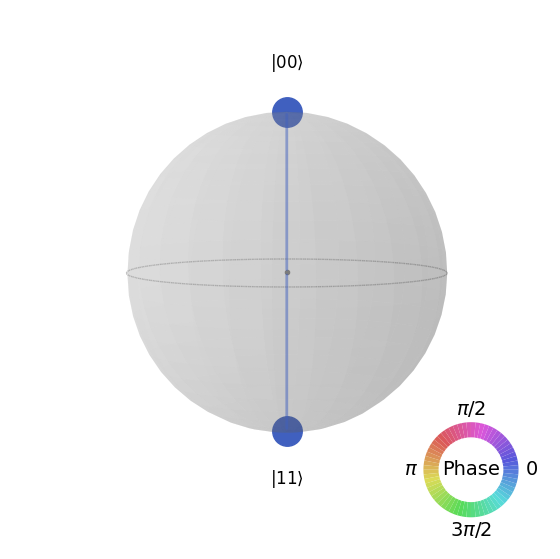

In [282]:
#qsphere visualization of the Bell state
plot_state_qsphere(state)

## Hinton visualization of the Bell state
Each entry is a sparce matrix element of the density matrix. The size of the square is proportional to the magnitude of the corresponding element, and the color indicates its sign (positive or negative). The Bell state $ |\Phi^+\rangle $ has non-zero elements at positions (0,0), (0,3), (3,0), and (3,3), which correspond to the terms $ |00\rangle \langle 00| $, $ |00\rangle \langle 11| $, $ |11\rangle \langle 00| $, and $ |11\rangle \langle 11| $. The color indicates the sign of the elements. 

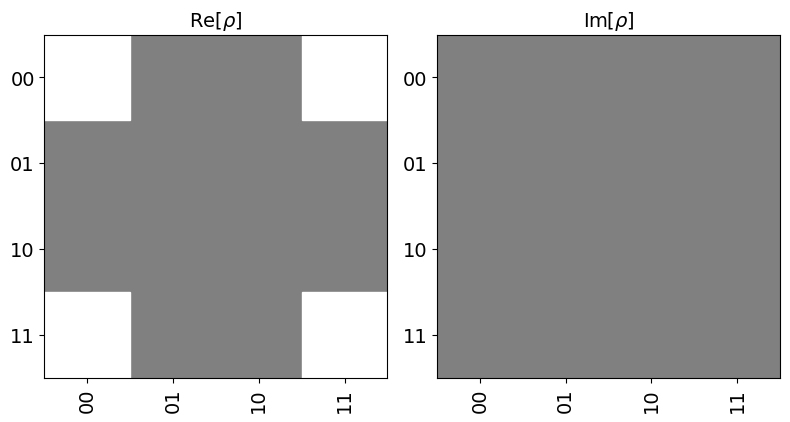

In [283]:
rho = DensityMatrix(state)
plot_state_hinton(rho)

## Plot state city visualization of the Bell state
The statevector $ |\Phi^+\rangle $ is converted into its density matrix $ |\Phi^+\rangle \langle \Phi^+| $. On the left, we see the real part of the density matrix, where the non-zero elements correspond to the terms $ |00\rangle \langle 00| $, $ |00\rangle \langle 11| $, $ |11\rangle \langle 00| $, and $ |11\rangle \langle 11| $. The imaginary part of the density matrix is zero, which is why we see no bars on the right. (Check how this looks for other states)

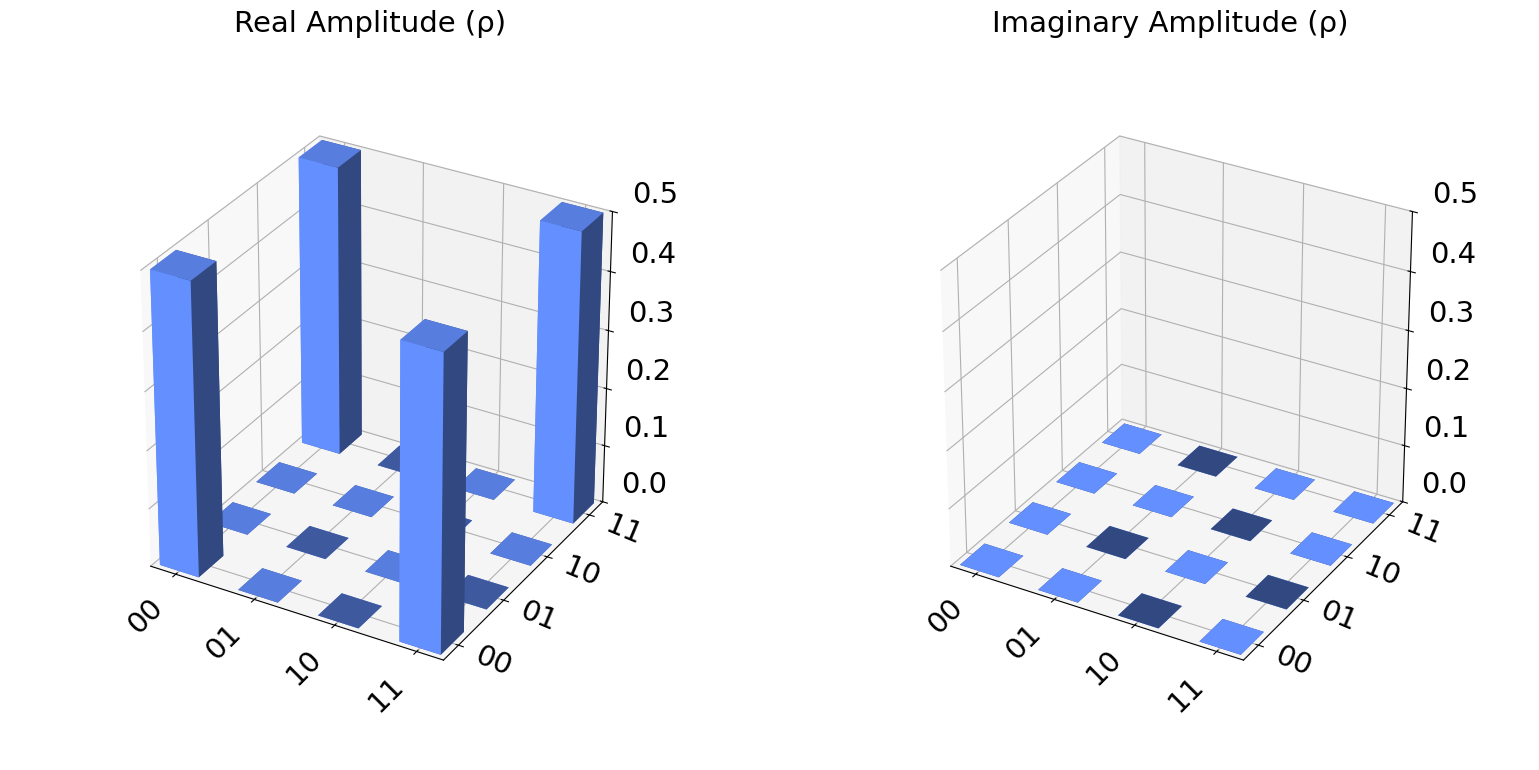

In [284]:
rho = DensityMatrix(state)
plot_state_city(rho)

---
## Run the Aer simulator with statevector method

This method allows us to obtain the statevector of the quantum state after applying the gates (it forms a  high performance classical simulator). This computes the full 2^n statevector for n qubits, which is useful for small systems to understand the quantum state. However, it is not scalable for large numbers of qubits due to the exponential growth of the state space. Note that this extraction of the statevector is not possible on real quantum hardware, where we can only obtain measurement outcomes (bitstrings) by performing measurements on the qubits. 

**Question:** How many experiments would you need to extract a full 2^n statevector by performing measurements on a real quantum device in terms of scaling?

In [285]:
from qiskit_aer import AerSimulator
print(AerSimulator().available_methods())

('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')


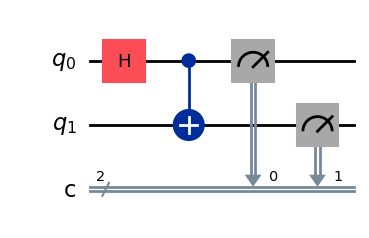

In [286]:
# initialize your quantum circuit here:
# exemplary Bell state circuit 
qc = QuantumCircuit(2, 2) # 2 qubits and 2 classical bits for measurement, use qc = QuantumCircuit(2) if you don't want to measure the qubits
qc.h(0)
qc.cx(0, 1)

# measure all qubits in the circuit
#qc.measure_all()

# measure each qubit to the corresponding classical bit
qc.measure(0, 0) # measure qubit 0 into classical bit 0
qc.measure(1, 1) # measure qubit 1 into classical bit 1

# visualize the circuit (with measurement and classical bits)
qc.draw('mpl')


### Sampling measurement outcomes:
So far we have seen the statevector, which is available in simulation. To mimic what a real quantum device would return, we need to now add measurements to our circuit and run it for a finite number of shots. 
Each shot returns a classical bitstring with a probability given by the Born rule (i.e., each shot returns a bitstring $x$ with probability $|c_x|^2 = |\langle x | \psi \rangle|^2$). The resulting distribution of outcomes (bitstrings) can be visualized as a histogram, which is a common way of representing the output of a quantum computation on real hardware. 

In [287]:
# run the circuit on the Aer simulator with statevector method to get the measurement counts: 
# statistical sampling of the statevector
simulator = AerSimulator(method='statevector') 
qc_t = transpile(qc, simulator)
result = simulator.run(qc_t, shots=10000).result()
counts = result.get_counts()
print("Measurement counts:", counts)

Measurement counts: {'00': 4982, '11': 5018}


 **Question:** What changes if we change the number of shots?

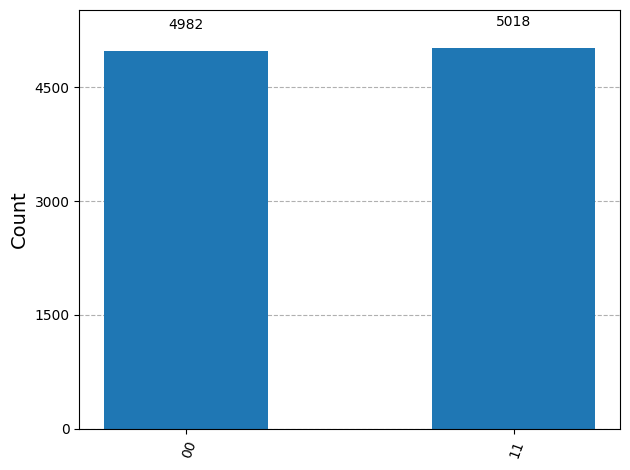

In [288]:
# visualize the outcome of the measurement as a histogram 
from qiskit.visualization import plot_histogram
plot_histogram(counts)

**Question:** What is transpilation and how does it affect the circuit?
